# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)

df = pd.read_csv('credit_risk_dataset.csv')
print(f"Розмір датасету: {df.shape}")
df.head()

Розмір датасету: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [3]:
(df['loan_status'].value_counts(normalize=True) * 100).round(2)

,proportion
loan_status,
0,78.18
1,21.82



---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]

missing_df = missing.to_frame('missing_count')
missing_df['dtype'] = df.dtypes.loc[missing.index]

missing_df

,missing_count,dtype
person_emp_length,895,float64
loan_int_rate,3116,float64


In [5]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [6]:
df[['person_emp_length', 'loan_int_rate']].isnull().sum()

,0
person_emp_length,0
loan_int_rate,0


In [7]:
df.describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.77,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.09,6322.09,3.08,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,8.49,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.11,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


In [8]:
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['person_income'] < lower_bound) | (df['person_income'] > upper_bound)]
outliers.shape

(1484, 12)

In [9]:
df['person_income'] = df['person_income'].clip(lower_bound, upper_bound)

In [10]:
df['person_income'].describe().round(2)

,person_income
count,32581.00
mean,62419.21
std,31810.27
min,4000.00
25%,38500.00
50%,55000.00
75%,79200.00
max,140250.00


In [12]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print('-------')
    print(df[col].value_counts(normalize=True).map('{:.2%}'.format))
print(df.groupby(col)['loan_status'].mean().sort_values(ascending=False))
print("\n")

-------
person_home_ownership
RENT        50.48%
MORTGAGE    41.26%
OWN          7.93%
OTHER        0.33%
Name: proportion, dtype: object
-------
loan_intent
EDUCATION            19.81%
MEDICAL              18.63%
VENTURE              17.55%
PERSONAL             16.95%
DEBTCONSOLIDATION    16.00%
HOMEIMPROVEMENT      11.06%
Name: proportion, dtype: object
-------
loan_grade
A    33.08%
B    32.08%
C    19.82%
D    11.13%
E     2.96%
F     0.74%
G     0.20%
Name: proportion, dtype: object
-------
cb_person_default_on_file
N    82.37%
Y    17.63%
Name: proportion, dtype: object
cb_person_default_on_file
Y    0.378068
N    0.183932
Name: loan_status, dtype: float64




In [13]:
fig = px.box(
    df,
    x='loan_status',
    y='person_income',
    title='Розподіл доходу залежно від статусу кредиту',
    labels={'person_income': 'Річний дохід', 'loan_status': 'Статус кредиту'},
    color='loan_status',
    color_discrete_map={'Погашено':'#2ecc71', 'Дефолт':'#e74c3c'}
)
fig.show()


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



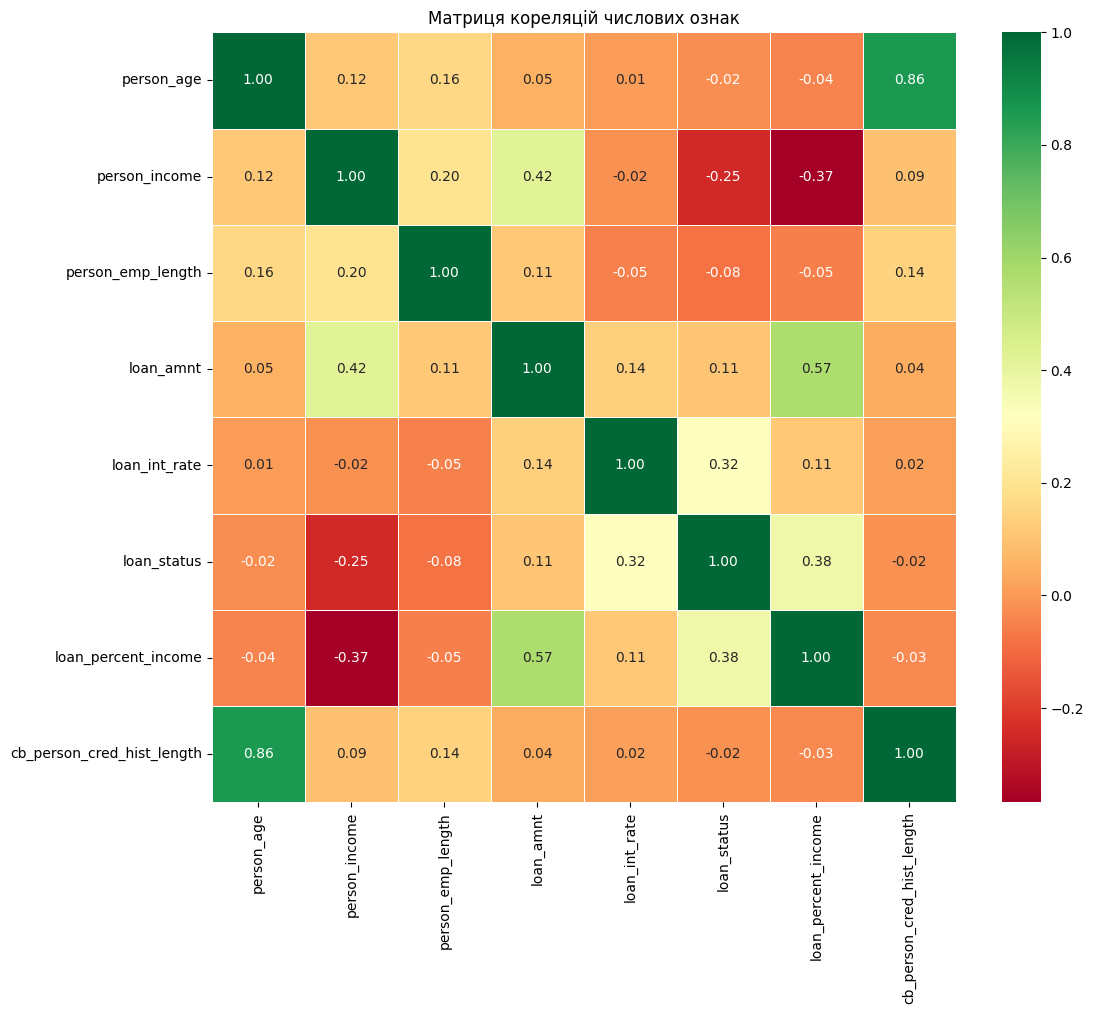

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

numerical_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Матриця кореляцій числових ознак')
plt.show()

In [15]:
df_final = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'], drop_first=True)

print(f"Кількість ознак після кодування: {df_final.shape[1]}")

Кількість ознак після кодування: 23


In [16]:
df_final.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True



---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [17]:
X = df_final.drop('loan_status', axis=1)
y = df_final['loan_status']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Розмір навчальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

Розмір навчальної вибірки: (26064, 22)
Розмір тестової вибірки: (6517, 22)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print("Модель успішно навчена!")

Модель успішно навчена!


In [20]:
y_train_pred = log_reg.predict(X_train_scaled)

y_test_pred = log_reg.predict(X_test_scaled)

print("Прогнози на тесті:", y_test_pred[:5])
print("Реальні значення: ", y_test.values[:5])

Прогнози на тесті: [0 0 0 0 0]
Реальні значення:  [0 0 0 0 0]



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


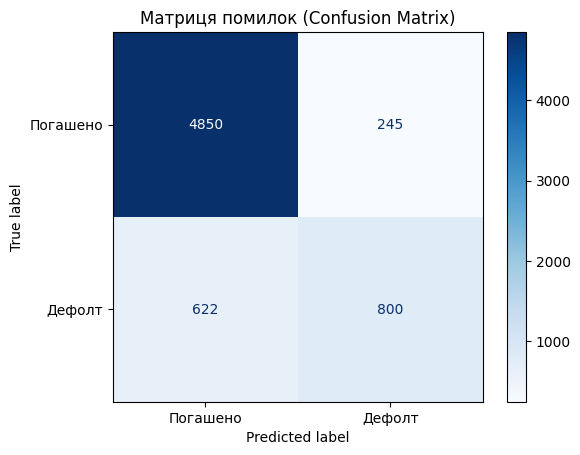

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Погашено', 'Дефолт'])

disp.plot(cmap='Blues')
plt.title('Матриця помилок (Confusion Matrix)')
plt.show()

In [22]:
from sklearn.metrics import classification_report

print("Звіт про класифікацію (Test Set):")
print(classification_report(y_test, y_test_pred))

Звіт про класифікацію (Test Set):
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5095
           1       0.77      0.56      0.65      1422

    accuracy                           0.87      6517
   macro avg       0.83      0.76      0.78      6517
weighted avg       0.86      0.87      0.86      6517



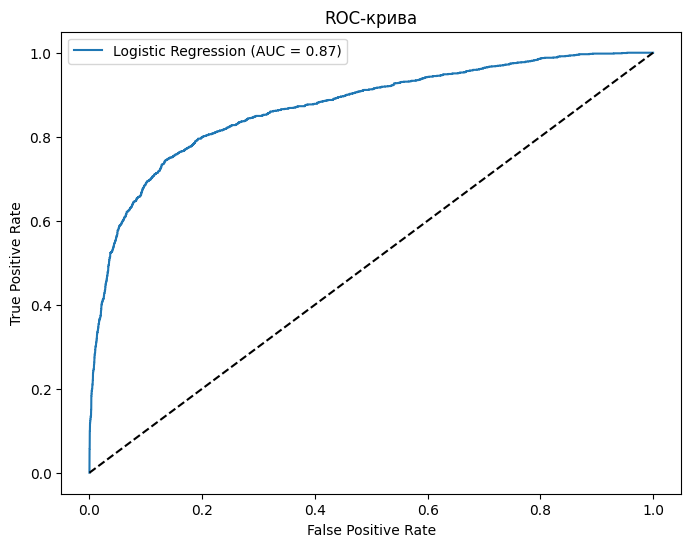

In [23]:
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_value = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-крива')
plt.legend()
plt.show()

AUC > 0.80: Вказує на хорошу роздільну здатність моделі. Вона значно краща за випадкове вгадування.

Баланс метрик: Якщо Recall для класу 1 значно нижчий за Precision, модель є "обережною" і пропускає багато дефолтів. У кредитуванні це небезпечно, тому іноді варто змінити поріг відсікання з 0.5 на нижчий (наприклад, 0.3).

loan_int_rate (Процентна ставка): Зазвичай має найбільший позитивний коефіцієнт. Чим вища ставка, тим більша ймовірність дефолту (борг стає "дорожчим").
person_income: Має від'ємний коефіцієнт — чим вищий дохід, тим менша ймовірність дефолту.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
results = []

for t in thresholds:
    # Перетворюємо ймовірності у класи за новим порогом
    y_pred_t = (y_probs >= t).astype(int)

    results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t),
        'Recall': recall_score(y_test, y_pred_t),
        'F1-Score': f1_score(y_test, y_pred_t)
    })

df_thresholds = pd.DataFrame(results)
print(df_thresholds.to_string(index=False))

 Threshold  Precision   Recall  F1-Score
       0.1   0.380836 0.877637  0.531177
       0.3   0.621936 0.713783  0.664702
       0.5   0.765550 0.562588  0.648561
       0.7   0.855932 0.355134  0.501988
       0.9   0.944724 0.132208  0.231956


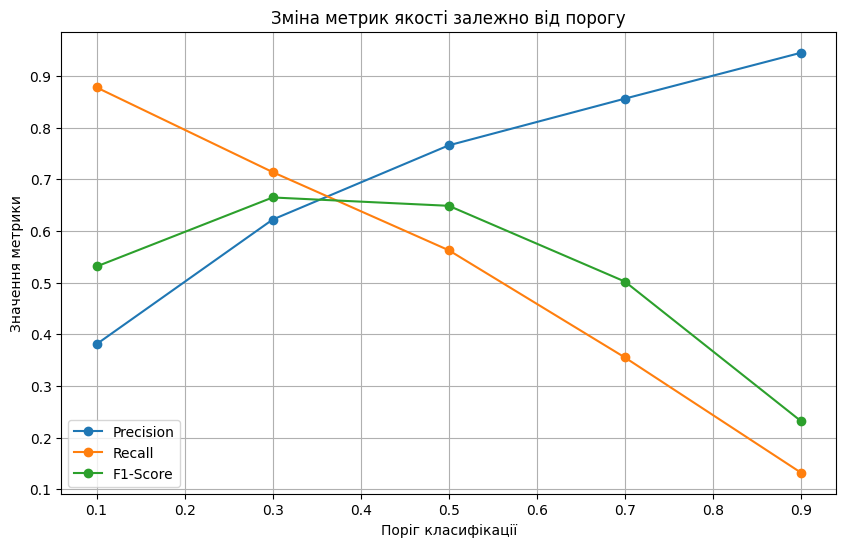

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df_thresholds['Threshold'], df_thresholds['Precision'], label='Precision', marker='o')
plt.plot(df_thresholds['Threshold'], df_thresholds['Recall'], label='Recall', marker='o')
plt.plot(df_thresholds['Threshold'], df_thresholds['F1-Score'], label='F1-Score', marker='o')

plt.xlabel('Поріг класифікації')
plt.ylabel('Значення метрики')
plt.title('Зміна метрик якості залежно від порогу')
plt.legend()
plt.grid(True)
plt.show()

Мінімізація збитків Поріг: $0.2$ – $0.3$ Ми хочемо максимізувати Recall. Нам краще помилково відмовити хорошому клієнту (втратити потенційний відсоток), ніж видати кредит дефолтному клієнту (втратити все тіло кредиту).Наслідок: Високий Recall, низький Precision.

Захоплення ринку Поріг: $0.5$ – $0.6$ Банк готовий ризикувати заради обсягу клієнтської бази.Наслідок: Вищий Precision (схвалюємо лише "надійних"), але пропускаємо більше дефолтів.

F1-Score Поріг: Точка, де F1-Score максимальний (зазвичай близько $0.35$ – $0.45$ для незбалансованих даних). Це баланс, де ми однаково зважаємо на точність і повноту.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

dt_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

y_probs_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
y_probs_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

threshold = 0.35
y_pred_dt = (y_probs_dt >= threshold).astype(int)
y_pred_rf = (y_probs_rf >= threshold).astype(int)

In [27]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importances.head(5))

                      Feature  Importance
5         loan_percent_income    0.215217
1               person_income    0.154733
4               loan_int_rate    0.127339
3                   loan_amnt    0.082783
9  person_home_ownership_RENT    0.072811


Для впровадження у бізнес-процес скорингу рекомендується використовувати Random Forest з порогом 0.35, оскільки він забезпечує максимальний захист капіталу банку при збереженні високої загальної точності.